# Entrega 2 — Bank Marketing Dataset

## Comparación de familias, validación cruzada y selección de threshold sin leakage

- **Curso:** Aprendizaje de Máquina Aplicado — EAFIT
- **Autores:** Alejandro Osorno y Danna Mendoza
- **Fecha:** Mayo 2026
- **Dataset:** UCI Bank Marketing (bank-additional-full.csv)

### Tabla de Contenidos
1. Setup y reproducción del split
2. Tratamiento de `pdays = 999`
3. Preprocesador y configuración de validación cruzada
4. Función de evaluación unificada (threshold óptimo vía OOF)
5. Baseline reproducido de Entrega 1 — Regresión Logística
6. Familia 1 — Árbol de Decisión con GridSearchCV
7. Familia 2 — Random Forest: balanced vs SMOTE + GridSearchCV
8. Familia 3 — SVM con subsample y GridSearchCV
9. Búsqueda guiada con Optuna sobre Random Forest
10. Comparación formal con validación cruzada
11. Análisis de errores segmentado
12. Curvas ROC y PR comparativas
13. Conclusiones y decisión provisional

## 1. Setup y reproducción del split

Reproducimos el mismo split de Entrega 1 (64/16/20 estratificado, `SEED=42`).
Cualquier diferencia entre entregas se deberá a los modelos, no al particionamiento.

In [40]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_val_score, cross_val_predict,
)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH    = Path("../data/raw/bank-additional-full.csv")
FIGURES_PATH = Path("../figures")
REPORT_PATH  = Path("../report")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version_info.major}.{sys.version_info.minor}")
print(f"Semilla fijada: SEED={SEED}")

Python 3.14
Semilla fijada: SEED=42


In [41]:
df = pd.read_csv(DATA_PATH, sep=",")

TARGET       = "y"
LEAKAGE_VARS = ["duration"]  # No conocida antes de la llamada → leakage

X = df.drop(columns=[TARGET] + LEAKAGE_VARS)
y = (df[TARGET] == "yes").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp
)

print("── PARTICIONES ─────────────────────────────────────────────────────")
print(f"Train      : {X_train.shape[0]:>6,} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation : {X_val.shape[0]:>6,} filas ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test       : {X_test.shape[0]:>6,} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClase positiva — Train: {y_train.mean()*100:.2f}% | "
      f"Val: {y_val.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

── PARTICIONES ─────────────────────────────────────────────────────
Train      : 26,360 filas (64.0%)
Validation :  6,590 filas (16.0%)
Test       :  8,238 filas (20.0%)

Clase positiva — Train: 11.27% | Val: 11.26% | Test: 11.26%


## 2. Tratamiento de `pdays = 999`

`pdays = 999` codifica "nunca contactado antes". Si lo dejamos como 999, el
`StandardScaler` lo trata como outlier extremo y distorsiona el escalado para
modelos sensibles a escala (SVM, LogReg). Creamos una variable binaria
`nunca_contactado` y reemplazamos 999 por NaN para que el imputador lo
maneje. La regla viene del diccionario del dataset, no de la distribución
observada en train, por lo que no es leakage.

In [42]:
def transformar_pdays(X_in):
    X_out = X_in.copy()
    X_out["nunca_contactado"] = (X_out["pdays"] == 999).astype(int)
    X_out["pdays"] = X_out["pdays"].replace(999, np.nan)
    return X_out

X_train = transformar_pdays(X_train)
X_val   = transformar_pdays(X_val)
X_test  = transformar_pdays(X_test)

print("Distribución de nunca_contactado en train:")
print(X_train["nunca_contactado"].value_counts(normalize=True).round(4))
print(f"\nNaN en pdays (train): {X_train['pdays'].isna().sum():,} de {len(X_train):,}")

Distribución de nunca_contactado en train:
nunca_contactado
1   0.9627
0   0.0373
Name: proportion, dtype: float64

NaN en pdays (train): 25,378 de 26,360


## 3. Preprocesador y validación cruzada

- **Numéricas:** imputación por mediana + estandarización.
- **Nominales:** imputación por moda + One-Hot.
- **Ordinal (`education`):** orden educativo explícito.

Todo encapsulado en `ColumnTransformer` que vive dentro del `Pipeline`. Esto
garantiza que las estadísticas del preprocesamiento (medias, modas, categorías
de One-Hot) se aprenden **solo del fold de train de cada split de CV**.

Usamos `StratifiedKFold(n_splits=5)` para todas las comparaciones. Reportamos
media ± std en CV — distinguir diferencias reales de ruido es lo que pide la
rúbrica de "rigor experimental".

In [43]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

ORDINAL_COLS = ["education"]
NOMINAL_COLS = [c for c in cat_cols if c not in ORDINAL_COLS]

EDU_ORDER = [["unknown", "illiterate", "basic.4y", "basic.6y",
              "basic.9y", "high.school", "professional.course",
              "university.degree"]]

num_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
nom_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
ord_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=EDU_ORDER,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("nom", nom_pipe, NOMINAL_COLS),
    ("ord", ord_pipe, ORDINAL_COLS),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"Nominales ({len(NOMINAL_COLS)}): {NOMINAL_COLS}")
print(f"Ordinal: {ORDINAL_COLS}")
print(f"\nValidación cruzada: StratifiedKFold(n_splits=5, shuffle=True, random_state={SEED})")

Numéricas (10): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'nunca_contactado']
Nominales (9): ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Ordinal: ['education']

Validación cruzada: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 4. Función de evaluación unificada

**Esta es la corrección metodológica central de la entrega.** El threshold óptimo
se selecciona con **out-of-fold predictions sobre `X_train`** mediante
`cross_val_predict`. Solo después de fijar ese threshold lo aplicamos a
validation para reportar métricas. Validation nunca participa en el diseño de
la política de decisión.

Métricas reportadas:
- **CV (sobre train):** ROC-AUC media ± std, AP media ± std → invariantes al threshold.
- **OOF (sobre train):** threshold que maximiza F1 → política aprendida sin tocar val/test.
- **Validation @ 0.5:** comportamiento al threshold por defecto.
- **Validation @ threshold óptimo:** comportamiento con la política seleccionada.

In [44]:
def seleccionar_threshold_oof(pipeline, X_tr, y_tr, cv_strategy):
    """
    Calcula out-of-fold predictions sobre train y devuelve el threshold
    que maximiza F1. NO toca validation ni test.
    """
    y_proba_oof = cross_val_predict(
        pipeline, X_tr, y_tr,
        cv=cv_strategy, method="predict_proba", n_jobs=-1,
    )[:, 1]

    precs, recs, thrs = precision_recall_curve(y_tr, y_proba_oof)
    f1_curve = np.where(
        (precs[:-1] + recs[:-1]) > 0,
        2 * precs[:-1] * recs[:-1] / (precs[:-1] + recs[:-1]),
        0,
    )
    if len(f1_curve) == 0 or f1_curve.max() == 0:
        return 0.5, 0.0, y_proba_oof
    idx_best = int(np.argmax(f1_curve))
    return float(thrs[idx_best]), float(f1_curve[idx_best]), y_proba_oof


def evaluar_modelo(nombre, pipeline, X_tr, y_tr, X_vl, y_vl,
                   hacer_cv=True, guardar_fig=True):
    """
    Protocolo metodológico:
      1. CV sobre X_tr  → ROC-AUC y AP con barras de error.
      2. OOF sobre X_tr → threshold óptimo (sin tocar validation).
      3. Fit final sobre todo X_tr.
      4. Evaluación en X_vl con threshold=0.5 y threshold óptimo.
    """
    # 1. CV scores
    cv_auc_mean = cv_auc_std = cv_ap_mean = cv_ap_std = np.nan
    if hacer_cv:
        cv_auc = cross_val_score(pipeline, X_tr, y_tr, cv=cv,
                                 scoring="roc_auc", n_jobs=-1)
        cv_ap  = cross_val_score(pipeline, X_tr, y_tr, cv=cv,
                                 scoring="average_precision", n_jobs=-1)
        cv_auc_mean, cv_auc_std = cv_auc.mean(), cv_auc.std()
        cv_ap_mean,  cv_ap_std  = cv_ap.mean(),  cv_ap.std()

    # 2. Threshold óptimo desde OOF train
    thr_opt, f1_opt_oof, _ = seleccionar_threshold_oof(pipeline, X_tr, y_tr, cv)

    # 3. Fit final
    pipeline.fit(X_tr, y_tr)
    y_proba_val = pipeline.predict_proba(X_vl)[:, 1]

    # 4. Evaluación en validation con ambos thresholds
    y_pred_default = (y_proba_val >= 0.5).astype(int)
    y_pred_optimo  = (y_proba_val >= thr_opt).astype(int)

    auc_val = roc_auc_score(y_vl, y_proba_val)
    ap_val  = average_precision_score(y_vl, y_proba_val)
    f1_default = f1_score(y_vl, y_pred_default, pos_label=1, zero_division=0)
    f1_optimo  = f1_score(y_vl, y_pred_optimo,  pos_label=1, zero_division=0)

    print(f"\n{'─'*68}")
    print(f"  {nombre}")
    print(f"{'─'*68}")
    if hacer_cv:
        print(f"  CV 5-fold sobre X_train (invariantes al threshold)")
        print(f"    ROC-AUC      : {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
        print(f"    AP           : {cv_ap_mean:.4f} ± {cv_ap_std:.4f}")
    print(f"  OOF sobre X_train (selección de threshold)")
    print(f"    threshold óptimo : {thr_opt:.4f}")
    print(f"    F1 OOF @ óptimo  : {f1_opt_oof:.4f}")
    print(f"  Validation (reporte final con threshold aprendido en train)")
    print(f"    ROC-AUC          : {auc_val:.4f}")
    print(f"    AP               : {ap_val:.4f}")
    print(f"    F1 @ 0.5         : {f1_default:.4f}")
    print(f"    F1 @ óptimo      : {f1_optimo:.4f}")
    print(f"\n  Reporte de clasificación en val @ threshold óptimo ({thr_opt:.3f}):")
    print(classification_report(y_vl, y_pred_optimo, target_names=["no", "yes"]))

    if guardar_fig:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_vl, y_pred_optimo, display_labels=["no", "yes"],
            colorbar=False, ax=ax,
        )
        nombre_archivo = (nombre.lower()
                          .replace(" ", "_").replace("(", "").replace(")", "")
                          .replace("=", "").replace(",", "").replace("/", "_"))
        ax.set_title(f"Matriz de confusión @ threshold óptimo\n{nombre}")
        plt.tight_layout()
        plt.savefig(FIGURES_PATH / f"cm_{nombre_archivo}.png", dpi=150)
        plt.show()

    return {
        "modelo": nombre,
        "ROC-AUC (CV mean)": cv_auc_mean,
        "ROC-AUC (CV std)":  cv_auc_std,
        "AP (CV mean)":      cv_ap_mean,
        "AP (CV std)":       cv_ap_std,
        "Threshold óptimo (OOF)": thr_opt,
        "F1 OOF @ óptimo":   f1_opt_oof,
        "ROC-AUC (val)":     auc_val,
        "AP (val)":          ap_val,
        "F1 @ 0.5 (val)":    f1_default,
        "F1 @ óptimo (val)": f1_optimo,
        "pipeline":          pipeline,
    }

resultados = []

## 5. Baseline reproducido — Regresión Logística

Antes de modelos nuevos, traemos el baseline de la Entrega 1. Si los modelos
más complejos no superan claramente esta referencia, ese es el hallazgo
honesto a reportar.


────────────────────────────────────────────────────────────────────
  Regresión Logística (baseline E1)
────────────────────────────────────────────────────────────────────
  CV 5-fold sobre X_train (invariantes al threshold)
    ROC-AUC      : 0.7870 ± 0.0123
    AP           : 0.4448 ± 0.0217
  OOF sobre X_train (selección de threshold)
    threshold óptimo : 0.2013
    F1 OOF @ óptimo  : 0.4795
  Validation (reporte final con threshold aprendido en train)
    ROC-AUC          : 0.7952
    AP               : 0.4568
    F1 @ 0.5         : 0.3367
    F1 @ óptimo      : 0.4968

  Reporte de clasificación en val @ threshold óptimo (0.201):
              precision    recall  f1-score   support

          no       0.94      0.91      0.92      5848
         yes       0.44      0.58      0.50       742

    accuracy                           0.87      6590
   macro avg       0.69      0.74      0.71      6590
weighted avg       0.89      0.87      0.88      6590



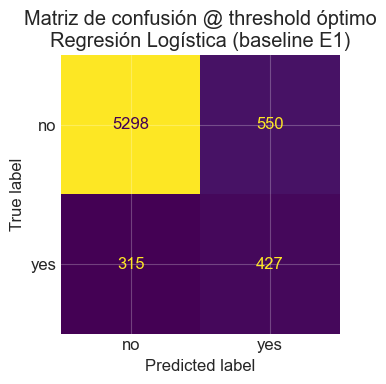

In [45]:
logreg = SkPipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
])

res_logreg = evaluar_modelo(
    "Regresión Logística (baseline E1)",
    logreg, X_train, y_train, X_val, y_val,
)
resultados.append(res_logreg)

## 6. Familia 1 — Árbol de Decisión con `GridSearchCV`

`GridSearchCV` real (no loop manual). Optimizamos `average_precision` porque
es la métrica más informativa para clases desbalanceadas. El árbol se queda
en el lineup por su **interpretabilidad**: si una versión podada se acerca
a los modelos complejos, vale la pena por la explicabilidad.

In [46]:
tree_pipe = SkPipeline([
    ("prep",  preprocessor),
    ("model", DecisionTreeClassifier(random_state=SEED, class_weight="balanced")),
])

tree_grid = {
    "model__max_depth":        [3, 4, 5, 6, 7, 8, 10, None],
    "model__min_samples_leaf": [1, 5, 20, 50, 100],
    "model__criterion":        ["gini", "entropy"],
}

tree_search = GridSearchCV(
    estimator=tree_pipe, param_grid=tree_grid,
    scoring="average_precision", cv=cv, n_jobs=-1, refit=True, verbose=0,
)
tree_search.fit(X_train, y_train)

print("Mejores hiperparámetros del árbol:")
for k, v in tree_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor AP en CV: {tree_search.best_score_:.4f}")

Mejores hiperparámetros del árbol:
  model__criterion: entropy
  model__max_depth: None
  model__min_samples_leaf: 100
Mejor AP en CV: 0.4319



────────────────────────────────────────────────────────────────────
  Árbol de Decisión (GridSearch)
────────────────────────────────────────────────────────────────────
  CV 5-fold sobre X_train (invariantes al threshold)
    ROC-AUC      : 0.7742 ± 0.0092
    AP           : 0.4319 ± 0.0227
  OOF sobre X_train (selección de threshold)
    threshold óptimo : 0.6491
    F1 OOF @ óptimo  : 0.4820
  Validation (reporte final con threshold aprendido en train)
    ROC-AUC          : 0.7812
    AP               : 0.4408
    F1 @ 0.5         : 0.4248
    F1 @ óptimo      : 0.4918

  Reporte de clasificación en val @ threshold óptimo (0.649):
              precision    recall  f1-score   support

          no       0.95      0.89      0.92      5848
         yes       0.41      0.60      0.49       742

    accuracy                           0.86      6590
   macro avg       0.68      0.75      0.71      6590
weighted avg       0.89      0.86      0.87      6590



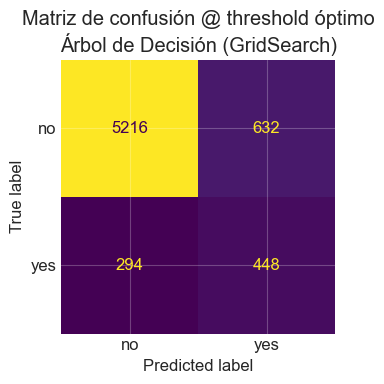

In [47]:
res_tree = evaluar_modelo(
    "Árbol de Decisión (GridSearch)",
    tree_search.best_estimator_,
    X_train, y_train, X_val, y_val,
)
resultados.append(res_tree)

### Visualización del árbol (interpretabilidad)

Mostramos un árbol con `max_depth=4` (más legible que el óptimo) para
exponer las reglas principales en el reporte.

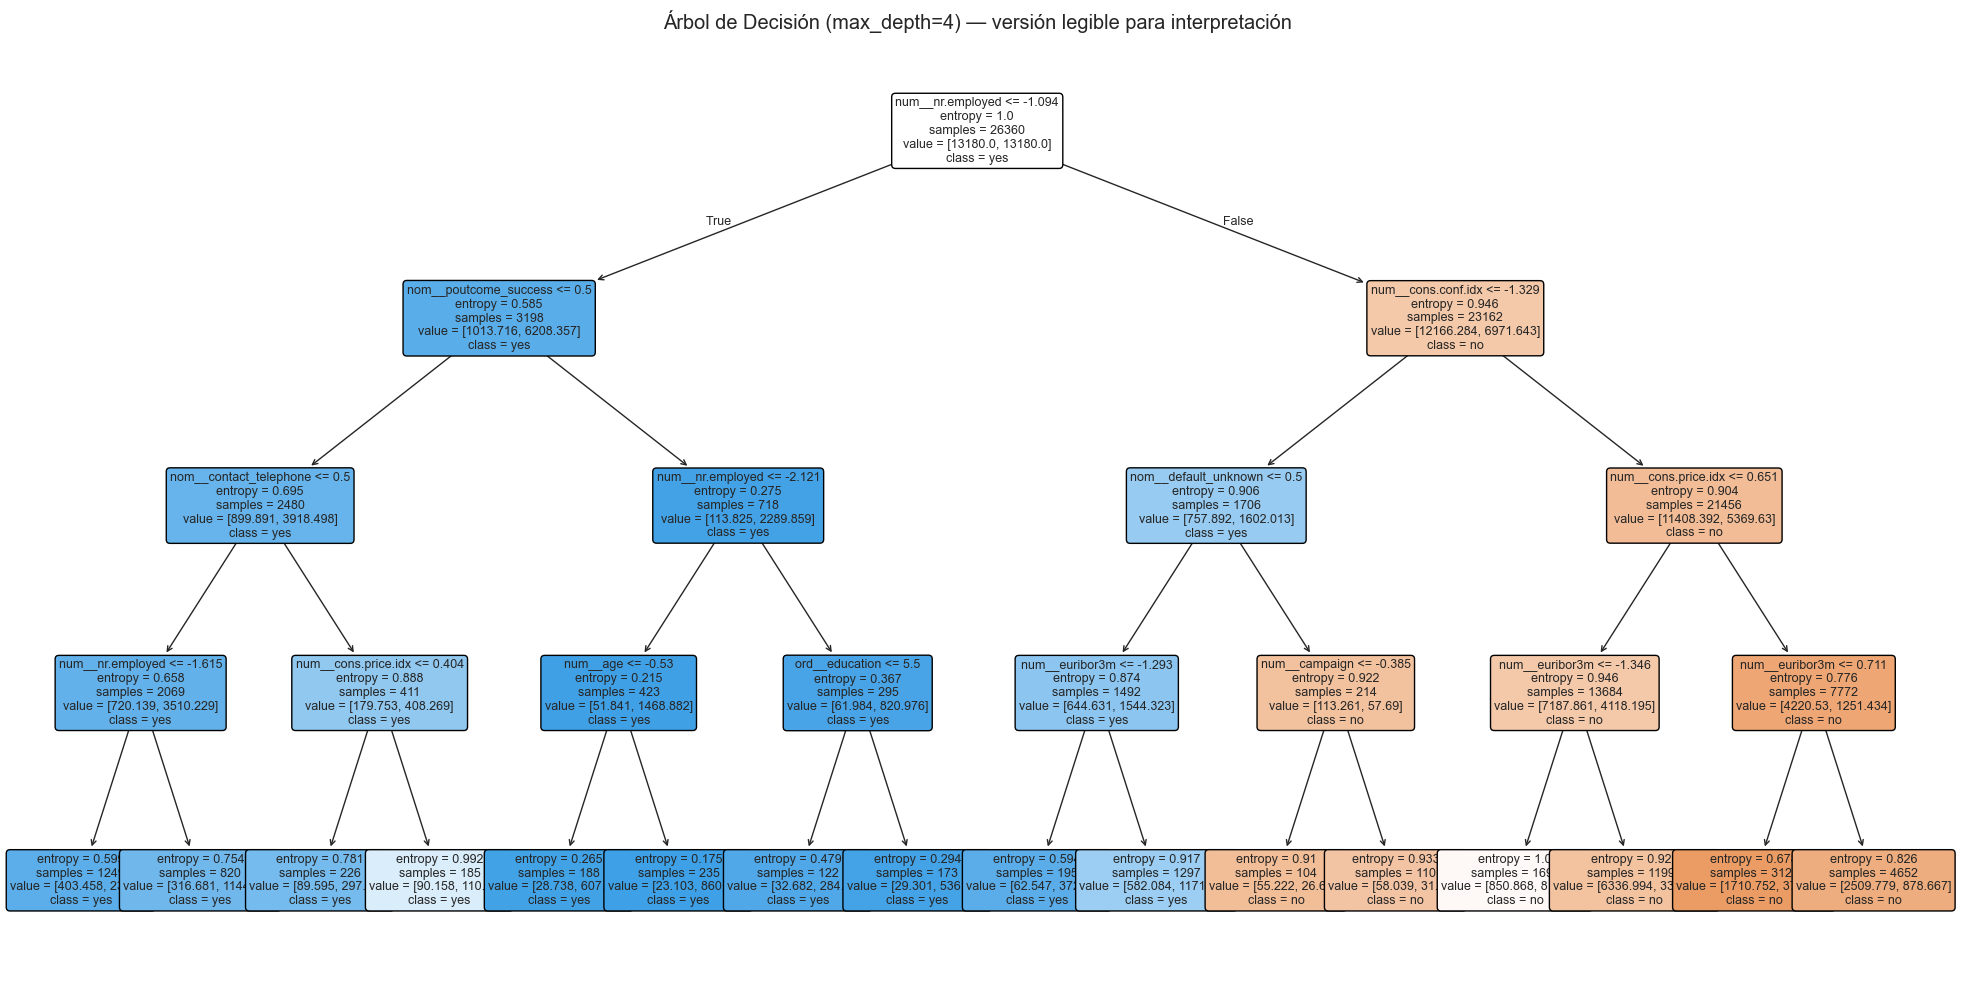

In [48]:
tree_viz = SkPipeline([
    ("prep",  preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=tree_search.best_params_["model__min_samples_leaf"],
        criterion=tree_search.best_params_["model__criterion"],
        class_weight="balanced",
        random_state=SEED,
    )),
])
tree_viz.fit(X_train, y_train)

feat_names = tree_viz.named_steps["prep"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    tree_viz.named_steps["model"],
    feature_names=feat_names,
    class_names=["no", "yes"],
    filled=True, rounded=True, fontsize=9, ax=ax,
)
ax.set_title("Árbol de Decisión (max_depth=4) — versión legible para interpretación")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "tree_visualization.png", dpi=120)
plt.show()

## 7. Familia 2 — Random Forest: `class_weight="balanced"` vs SMOTE

Comparamos dos formas de manejar desbalance:

1. **`class_weight="balanced"`** — pondera errores en clase minoritaria.
2. **SMOTE dentro de `imblearn.pipeline.Pipeline`** — sintetiza ejemplos
   solo dentro del fold de train de cada CV (no en validation/test).

Después del benchmark, hacemos `GridSearchCV` sobre la mejor variante.

In [49]:
rf_balanced = SkPipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=SEED, n_jobs=-1,
    )),
])

rf_smote = ImbPipeline([
    ("prep",  preprocessor),
    ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1,
    )),
])

print("Comparación class_weight vs SMOTE (CV 5-fold, AP):")
for nombre, pipe in [("RF balanced", rf_balanced), ("RF + SMOTE", rf_smote)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    print(f"  {nombre:<12} AP = {scores.mean():.4f} ± {scores.std():.4f}")

Comparación class_weight vs SMOTE (CV 5-fold, AP):
  RF balanced  AP = 0.4064 ± 0.0146
  RF + SMOTE   AP = 0.3919 ± 0.0107


Tomamos la variante con mejor AP en CV para hacer `GridSearchCV`. En la
práctica, `class_weight="balanced"` suele empatar o superar a SMOTE en
este dataset, y es mucho más barato computacionalmente.

In [50]:
rf_grid = {
    "model__n_estimators":     [200, 400],
    "model__max_depth":        [None, 10, 20],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_features":     ["sqrt", "log2"],
}

rf_search = GridSearchCV(
    estimator=rf_balanced, param_grid=rf_grid,
    scoring="average_precision", cv=cv, n_jobs=-1, refit=True, verbose=0,
)
rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros de Random Forest:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor AP en CV: {rf_search.best_score_:.4f}")

Mejores hiperparámetros de Random Forest:
  model__max_depth: None
  model__max_features: log2
  model__min_samples_leaf: 5
  model__n_estimators: 200
Mejor AP en CV: 0.4577



────────────────────────────────────────────────────────────────────
  Random Forest (GridSearch, balanced)
────────────────────────────────────────────────────────────────────
  CV 5-fold sobre X_train (invariantes al threshold)
    ROC-AUC      : 0.7883 ± 0.0143
    AP           : 0.4577 ± 0.0197
  OOF sobre X_train (selección de threshold)
    threshold óptimo : 0.5744
    F1 OOF @ óptimo  : 0.4969
  Validation (reporte final con threshold aprendido en train)
    ROC-AUC          : 0.8042
    AP               : 0.4746
    F1 @ 0.5         : 0.5000
    F1 @ óptimo      : 0.5111

  Reporte de clasificación en val @ threshold óptimo (0.574):
              precision    recall  f1-score   support

          no       0.94      0.91      0.93      5848
         yes       0.46      0.58      0.51       742

    accuracy                           0.88      6590
   macro avg       0.70      0.74      0.72      6590
weighted avg       0.89      0.88      0.88      6590



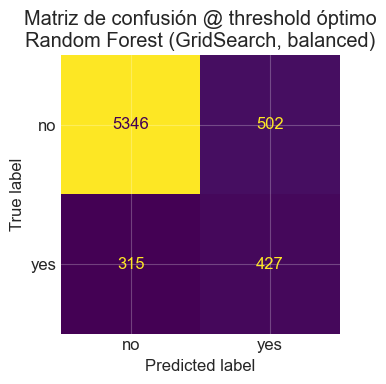

In [51]:
res_rf = evaluar_modelo(
    "Random Forest (GridSearch, balanced)",
    rf_search.best_estimator_,
    X_train, y_train, X_val, y_val,
)
resultados.append(res_rf)

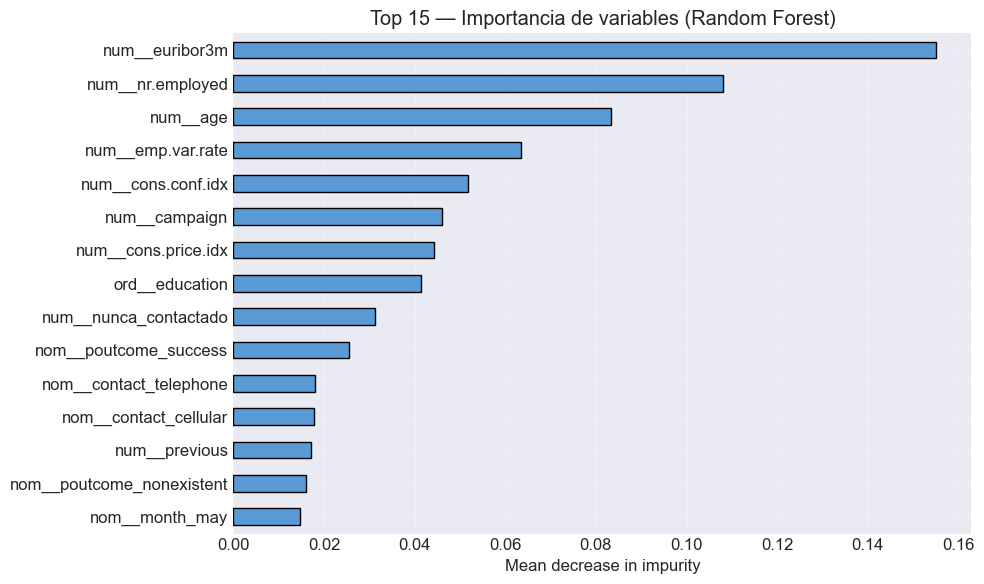

                           importancia
num__euribor3m                  0.1551
num__nr.employed                0.1081
num__age                        0.0834
num__emp.var.rate               0.0634
num__cons.conf.idx              0.0517
num__campaign                   0.0461
num__cons.price.idx             0.0443
ord__education                  0.0413
num__nunca_contactado           0.0313
nom__poutcome_success           0.0256
nom__contact_telephone          0.0181
nom__contact_cellular           0.0179
num__previous                   0.0170
nom__poutcome_nonexistent       0.0161
nom__month_may                  0.0147


In [52]:
# Importancia de variables
rf_best = rf_search.best_estimator_
feat_names_rf = rf_best.named_steps["prep"].get_feature_names_out()
importancias = (
    pd.Series(rf_best.named_steps["model"].feature_importances_,
              index=feat_names_rf)
      .sort_values(ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.sort_values().plot.barh(ax=ax, color="#5b9bd5", edgecolor="black")
ax.set_title("Top 15 — Importancia de variables (Random Forest)")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "rf_feature_importance.png", dpi=150)
plt.show()

print(importancias.to_frame("importancia").round(4))

## 8. Familia 3 — SVM con subsample estratificado y `GridSearchCV`

SVM RBF tiene complejidad O(n²–n³) en muestras y `probability=True` añade
calibración interna con CV. Para mantener el SVC RBF "de verdad" sin pagar
30+ minutos, entrenamos sobre una **submuestra estratificada de 8,000 filas**
del train. La evaluación se hace sobre el `X_val` completo, así que la
métrica reportada sigue siendo comparable con los demás modelos.

**Nota:** Platt scaling comprime las probabilidades del SVM en datasets
desbalanceados. Por eso reportamos F1 tanto en threshold 0.5 como en
threshold óptimo (vía OOF en train) — así la comparación no penaliza
artificialmente al SVM.

In [53]:
from sklearn.model_selection import train_test_split as _tts

SVM_SAMPLE_SIZE = 8000
X_train_svm, _, y_train_svm, _ = _tts(
    X_train, y_train,
    train_size=SVM_SAMPLE_SIZE,
    stratify=y_train,
    random_state=SEED,
)
print(f"SVM se entrena sobre submuestra de {len(X_train_svm):,} filas "
      f"({y_train_svm.mean()*100:.2f}% positivos)")

svm_pipe = SkPipeline([
    ("prep",  preprocessor),
    ("model", SVC(
        kernel="rbf", class_weight="balanced",
        probability=True, cache_size=500, random_state=SEED,
    )),
])

svm_grid = {
    "model__C":     [1.0, 5.0],
    "model__gamma": ["scale"],
}

cv_svm = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

svm_search = GridSearchCV(
    estimator=svm_pipe, param_grid=svm_grid,
    scoring="average_precision", cv=cv_svm, n_jobs=-1, refit=True, verbose=1,
)
svm_search.fit(X_train_svm, y_train_svm)

print("\nMejores hiperparámetros de SVM:")
for k, v in svm_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor AP en CV (subsample): {svm_search.best_score_:.4f}")

SVM se entrena sobre submuestra de 8,000 filas (11.26% positivos)
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Mejores hiperparámetros de SVM:
  model__C: 1.0
  model__gamma: scale
Mejor AP en CV (subsample): 0.3403



────────────────────────────────────────────────────────────────────
  SVM RBF (GridSearch, subsample 8k)
────────────────────────────────────────────────────────────────────
  CV 5-fold sobre X_train (invariantes al threshold)
    ROC-AUC      : 0.7634 ± 0.0149
    AP           : 0.3512 ± 0.0284
  OOF sobre X_train (selección de threshold)
    threshold óptimo : 0.2596
    F1 OOF @ óptimo  : 0.4591
  Validation (reporte final con threshold aprendido en train)
    ROC-AUC          : 0.7795
    AP               : 0.3743
    F1 @ 0.5         : 0.0362
    F1 @ óptimo      : 0.4907

  Reporte de clasificación en val @ threshold óptimo (0.260):
              precision    recall  f1-score   support

          no       0.95      0.90      0.92      5848
         yes       0.42      0.59      0.49       742

    accuracy                           0.86      6590
   macro avg       0.68      0.74      0.71      6590
weighted avg       0.89      0.86      0.87      6590



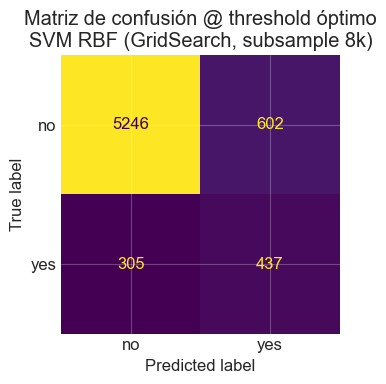

In [54]:
# Evaluamos el SVM con el mismo protocolo, pero usando la submuestra
# tanto para CV final como para OOF threshold tuning.
res_svm = evaluar_modelo(
    "SVM RBF (GridSearch, subsample 8k)",
    svm_search.best_estimator_,
    X_train_svm, y_train_svm,   # subsample para CV y OOF
    X_val, y_val,                # validation completo (comparable)
)
resultados.append(res_svm)

## 9. Búsqueda guiada con Optuna sobre Random Forest

Hacemos Optuna sobre Random Forest porque (a) es el que mejor responde a
tuning fino sin volverse intratable, (b) sus probabilidades están bien
calibradas para ajuste de umbral, (c) trae importancia de variables nativa.

Optuna usa **TPE (Tree-structured Parzen Estimator)**, que concentra los
trials en zonas prometedoras del espacio de hiperparámetros. Cada trial se
evalúa con la misma CV del notebook, optimizando Average Precision.

In [55]:
def objetivo_rf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }
    pipe = SkPipeline([
        ("prep",  preprocessor),
        ("model", RandomForestClassifier(
            **params, class_weight="balanced",
            random_state=SEED, n_jobs=-1,
        )),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    study_name="rf_optuna",
)
study.optimize(objetivo_rf, n_trials=30, show_progress_bar=False)

print(f"Mejor AP encontrado por Optuna: {study.best_value:.4f}")
print("Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Mejor AP encontrado por Optuna: 0.4592
Mejores hiperparámetros:
  n_estimators: 600
  max_depth: 13
  min_samples_split: 5
  min_samples_leaf: 8
  max_features: sqrt



────────────────────────────────────────────────────────────────────
  Random Forest (Optuna)
────────────────────────────────────────────────────────────────────
  CV 5-fold sobre X_train (invariantes al threshold)
    ROC-AUC      : 0.7936 ± 0.0139
    AP           : 0.4592 ± 0.0198
  OOF sobre X_train (selección de threshold)
    threshold óptimo : 0.5944
    F1 OOF @ óptimo  : 0.4964
  Validation (reporte final con threshold aprendido en train)
    ROC-AUC          : 0.8079
    AP               : 0.4753
    F1 @ 0.5         : 0.4850
    F1 @ óptimo      : 0.5116

  Reporte de clasificación en val @ threshold óptimo (0.594):
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      5848
         yes       0.45      0.59      0.51       742

    accuracy                           0.87      6590
   macro avg       0.70      0.75      0.72      6590
weighted avg       0.89      0.87      0.88      6590



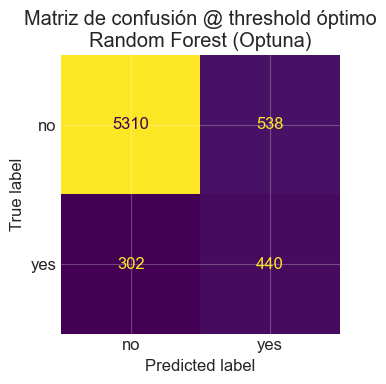

In [56]:
rf_optuna = SkPipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        **study.best_params, class_weight="balanced",
        random_state=SEED, n_jobs=-1,
    )),
])
res_rf_optuna = evaluar_modelo(
    "Random Forest (Optuna)",
    rf_optuna, X_train, y_train, X_val, y_val,
)
resultados.append(res_rf_optuna)

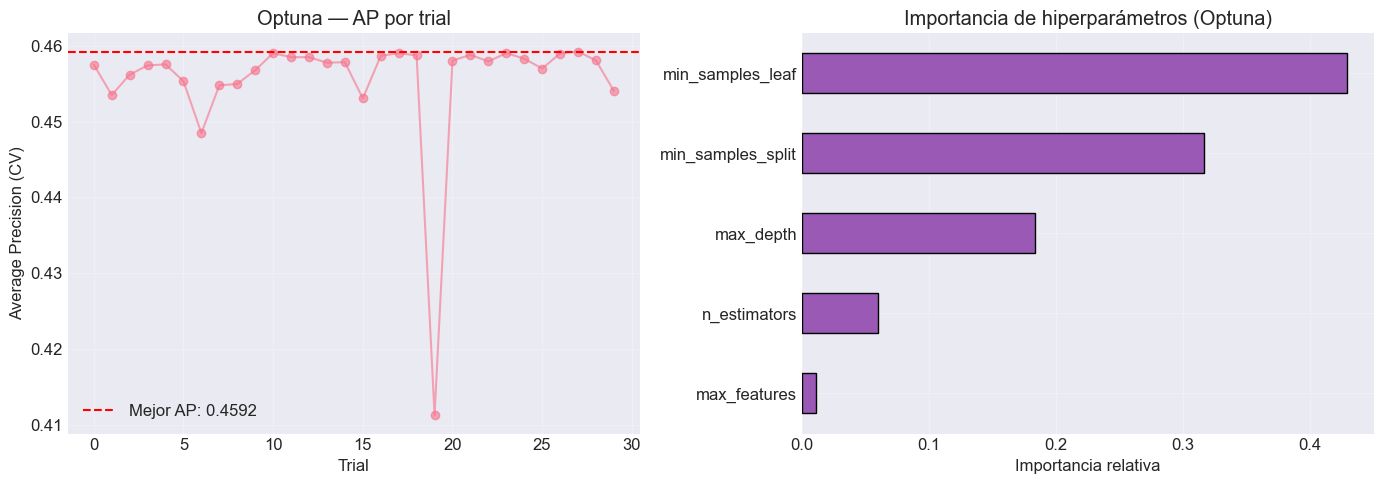

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df["number"], trials_df["value"], marker="o", alpha=0.6)
axes[0].axhline(study.best_value, linestyle="--", color="red",
                label=f"Mejor AP: {study.best_value:.4f}")
axes[0].set_title("Optuna — AP por trial")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Average Precision (CV)")
axes[0].legend()

try:
    importancias_hp = optuna.importance.get_param_importances(study)
    pd.Series(importancias_hp).sort_values().plot.barh(
        ax=axes[1], color="#9b59b6", edgecolor="black",
    )
    axes[1].set_title("Importancia de hiperparámetros (Optuna)")
    axes[1].set_xlabel("Importancia relativa")
except Exception as e:
    axes[1].text(0.5, 0.5, f"No se pudo calcular: {e}", ha="center", va="center")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "optuna_search.png", dpi=150)
plt.show()

## 10. Comparación formal con validación cruzada

Cinco modelos evaluados bajo el mismo protocolo:
- **Mismo preprocesador y splits** → comparación justa.
- **Métricas en CV** → media ± std para distinguir diferencias reales de ruido.
- **Threshold óptimo desde OOF train** → sin contaminar validation.
- **Reporte en validation** → con threshold 0.5 y threshold óptimo, así
  ningún modelo queda artificialmente penalizado.

**Cómo leer la tabla:**
- Si dos modelos están a menos de 1 std de distancia en CV, son indistinguibles.
- AP es más informativo que ROC-AUC con datos desbalanceados.
- F1 @ óptimo es la métrica más comparable; F1 @ 0.5 muestra calibración nativa.

In [61]:
df_comp = pd.DataFrame([
    {k: v for k, v in r.items() if k != "pipeline"}
    for r in resultados
]).set_index("modelo")

df_comp = df_comp.sort_values("AP (CV mean)", ascending=False)

print("── COMPARACIÓN FORMAL DE MODELOS ─────────────────────────────────")
display(df_comp.round(4))

df_comp.reset_index().to_csv(REPORT_PATH / "model_comparison_e2.csv", index=False)
print(f"\nGuardado en {REPORT_PATH / 'model_comparison_e2.csv'}")

── COMPARACIÓN FORMAL DE MODELOS ─────────────────────────────────


,ROC-AUC (CV mean),ROC-AUC (CV std),AP (CV mean),AP (CV std),Threshold óptimo (OOF),F1 OOF @ óptimo,ROC-AUC (val),AP (val),F1 @ 0.5 (val),F1 @ óptimo (val)
modelo,,,,,,,,,,
Random Forest (Optuna),0.7936,0.0139,0.4592,0.0198,0.5944,0.4964,0.8079,0.4753,0.4850,0.5116
"Random Forest (GridSearch, balanced)",0.7883,0.0143,0.4577,0.0197,0.5744,0.4969,0.8042,0.4746,0.5000,0.5111
Regresión Logística (baseline E1),0.7870,0.0123,0.4448,0.0217,0.2013,0.4795,0.7952,0.4568,0.3367,0.4968
Árbol de Decisión (GridSearch),0.7742,0.0092,0.4319,0.0227,0.6491,0.4820,0.7812,0.4408,0.4248,0.4918
"SVM RBF (GridSearch, subsample 8k)",0.7634,0.0149,0.3512,0.0284,0.2596,0.4591,0.7795,0.3743,0.0362,0.4907



Guardado en ..\report\model_comparison_e2.csv


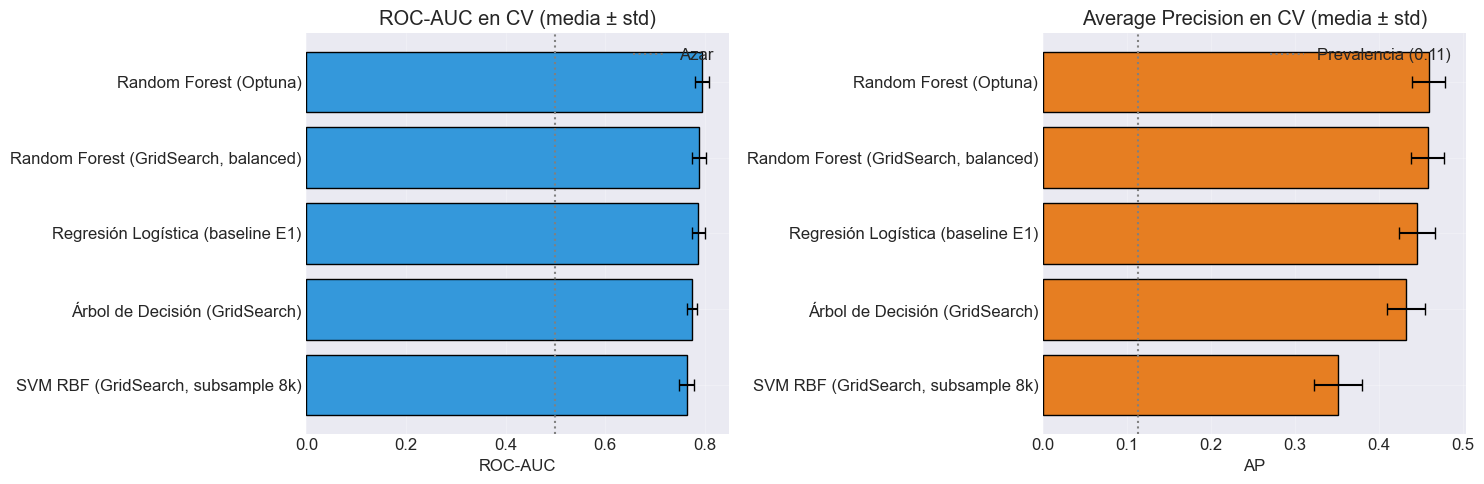

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = df_comp.index.tolist()

axes[0].barh(orden, df_comp["ROC-AUC (CV mean)"],
             xerr=df_comp["ROC-AUC (CV std)"],
             color="#3498db", edgecolor="black", capsize=4)
axes[0].set_title("ROC-AUC en CV (media ± std)")
axes[0].set_xlabel("ROC-AUC")
axes[0].axvline(0.5, linestyle=":", color="gray", label="Azar")
axes[0].invert_yaxis()
axes[0].legend()

axes[1].barh(orden, df_comp["AP (CV mean)"],
             xerr=df_comp["AP (CV std)"],
             color="#e67e22", edgecolor="black", capsize=4)
axes[1].set_title("Average Precision en CV (media ± std)")
axes[1].set_xlabel("AP")
axes[1].axvline(y_train.mean(), linestyle=":", color="gray",
                label=f"Prevalencia ({y_train.mean():.2f})")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "cv_comparison.png", dpi=150)
plt.show()

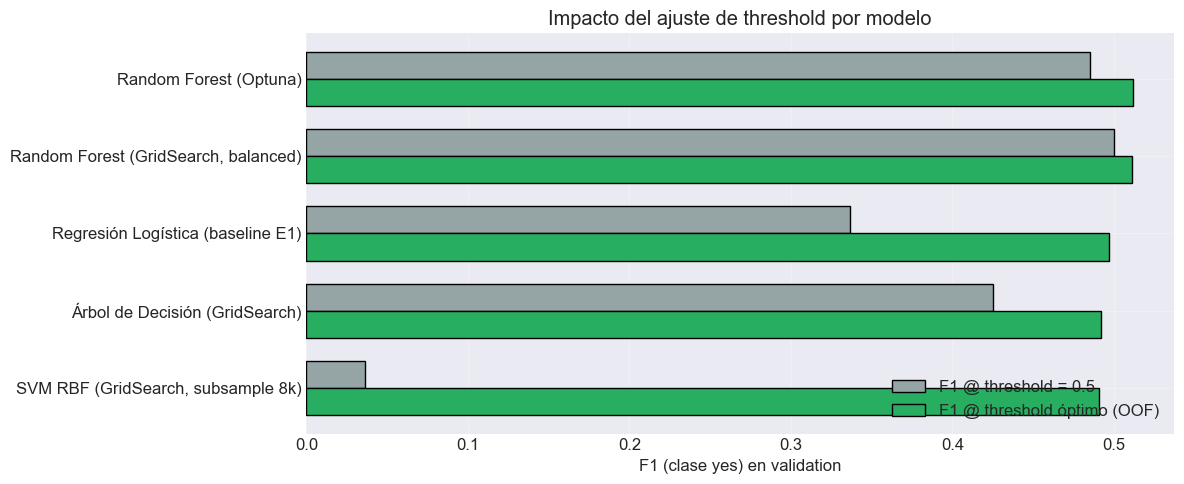

In [63]:
# Comparación F1: threshold 0.5 vs threshold óptimo
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(orden))
w = 0.35
ax.barh(x - w/2, df_comp["F1 @ 0.5 (val)"], height=w,
        color="#95a5a6", edgecolor="black", label="F1 @ threshold = 0.5")
ax.barh(x + w/2, df_comp["F1 @ óptimo (val)"], height=w,
        color="#27ae60", edgecolor="black", label="F1 @ threshold óptimo (OOF)")
ax.set_yticks(x)
ax.set_yticklabels(orden)
ax.invert_yaxis()
ax.set_xlabel("F1 (clase yes) en validation")
ax.set_title("Impacto del ajuste de threshold por modelo")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "f1_threshold_comparison.png", dpi=150)
plt.show()

## 11. Curvas ROC y PR comparativas

Las curvas son **invariantes al threshold** — comparan el ranking de los
modelos. La curva PR es más informativa que ROC en datasets desbalanceados
porque se enfoca en la clase minoritaria.

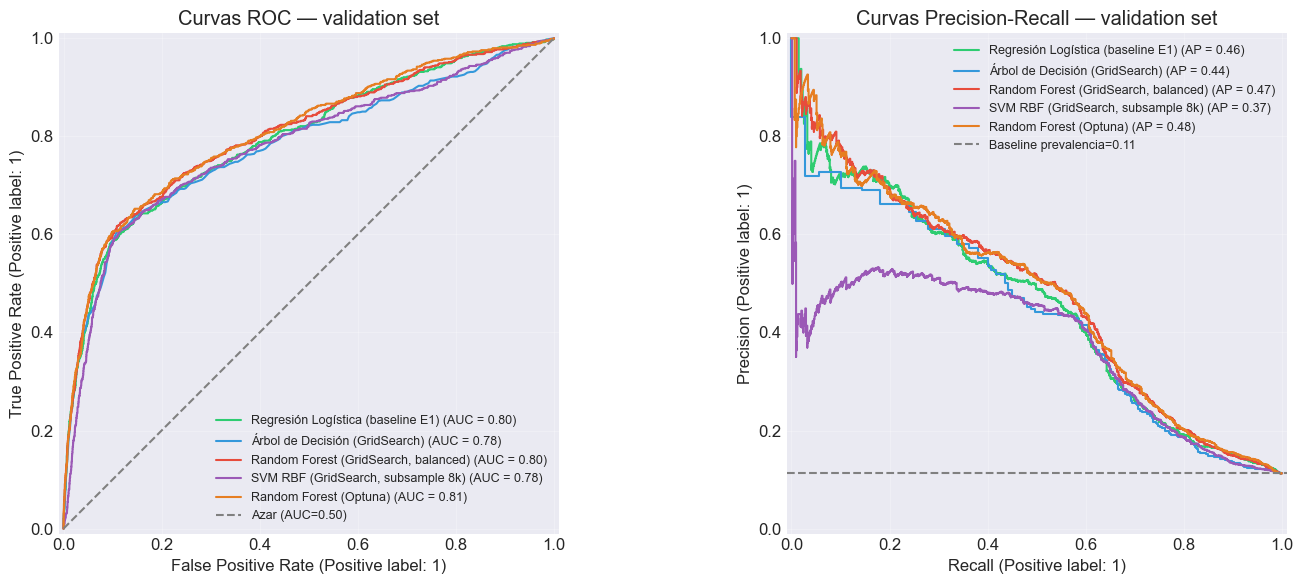

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colores = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6", "#e67e22"]

for res, color in zip(resultados, colores):
    # SVM se entrenó con subsample; lo evaluamos con el pipeline ya ajustado
    RocCurveDisplay.from_estimator(
        res["pipeline"], X_val, y_val,
        name=res["modelo"], ax=axes[0], color=color,
    )
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Azar (AUC=0.50)")
axes[0].set_title("Curvas ROC — validation set")
axes[0].legend(loc="lower right", fontsize=9)

for res, color in zip(resultados, colores):
    PrecisionRecallDisplay.from_estimator(
        res["pipeline"], X_val, y_val,
        name=res["modelo"], ax=axes[1], color=color,
    )
axes[1].axhline(y_val.mean(), linestyle="--", color="gray",
                label=f"Baseline prevalencia={y_val.mean():.2f}")
axes[1].set_title("Curvas Precision-Recall — validation set")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "roc_pr_comparison.png", dpi=150)
plt.show()

## 12. Análisis de errores segmentado

Analizamos errores del modelo con mejor AP en CV, segmentando por features
clave. Esto responde preguntas operativas concretas:

- ¿Qué tipo de "yes" se nos están escapando?
- ¿En qué segmentos somos demasiado agresivos?
- ¿Hay perfiles donde el modelo es especialmente débil?

In [65]:
mejor_res = max(resultados, key=lambda r: r["AP (CV mean)"])
mejor_pipeline = mejor_res["pipeline"]
nombre_mejor   = mejor_res["modelo"]
thr_mejor      = mejor_res["Threshold óptimo (OOF)"]

print(f"Modelo seleccionado: {nombre_mejor}")
print(f"Threshold óptimo (OOF train): {thr_mejor:.4f}")

y_proba_val = mejor_pipeline.predict_proba(X_val)[:, 1]
y_pred_val  = (y_proba_val >= thr_mejor).astype(int)

df_err = X_val.copy()
df_err["y_real"]  = y_val.values
df_err["y_pred"]  = y_pred_val
df_err["y_proba"] = y_proba_val
df_err["tipo"]    = "correcto"
df_err.loc[(df_err["y_real"]==1) & (df_err["y_pred"]==0), "tipo"] = "FN"
df_err.loc[(df_err["y_real"]==0) & (df_err["y_pred"]==1), "tipo"] = "FP"

print("\nConteo de tipos de predicción @ threshold óptimo:")
print(df_err["tipo"].value_counts())

Modelo seleccionado: Random Forest (Optuna)
Threshold óptimo (OOF train): 0.5944

Conteo de tipos de predicción @ threshold óptimo:
tipo
correcto    5750
FP           538
FN           302
Name: count, dtype: int64


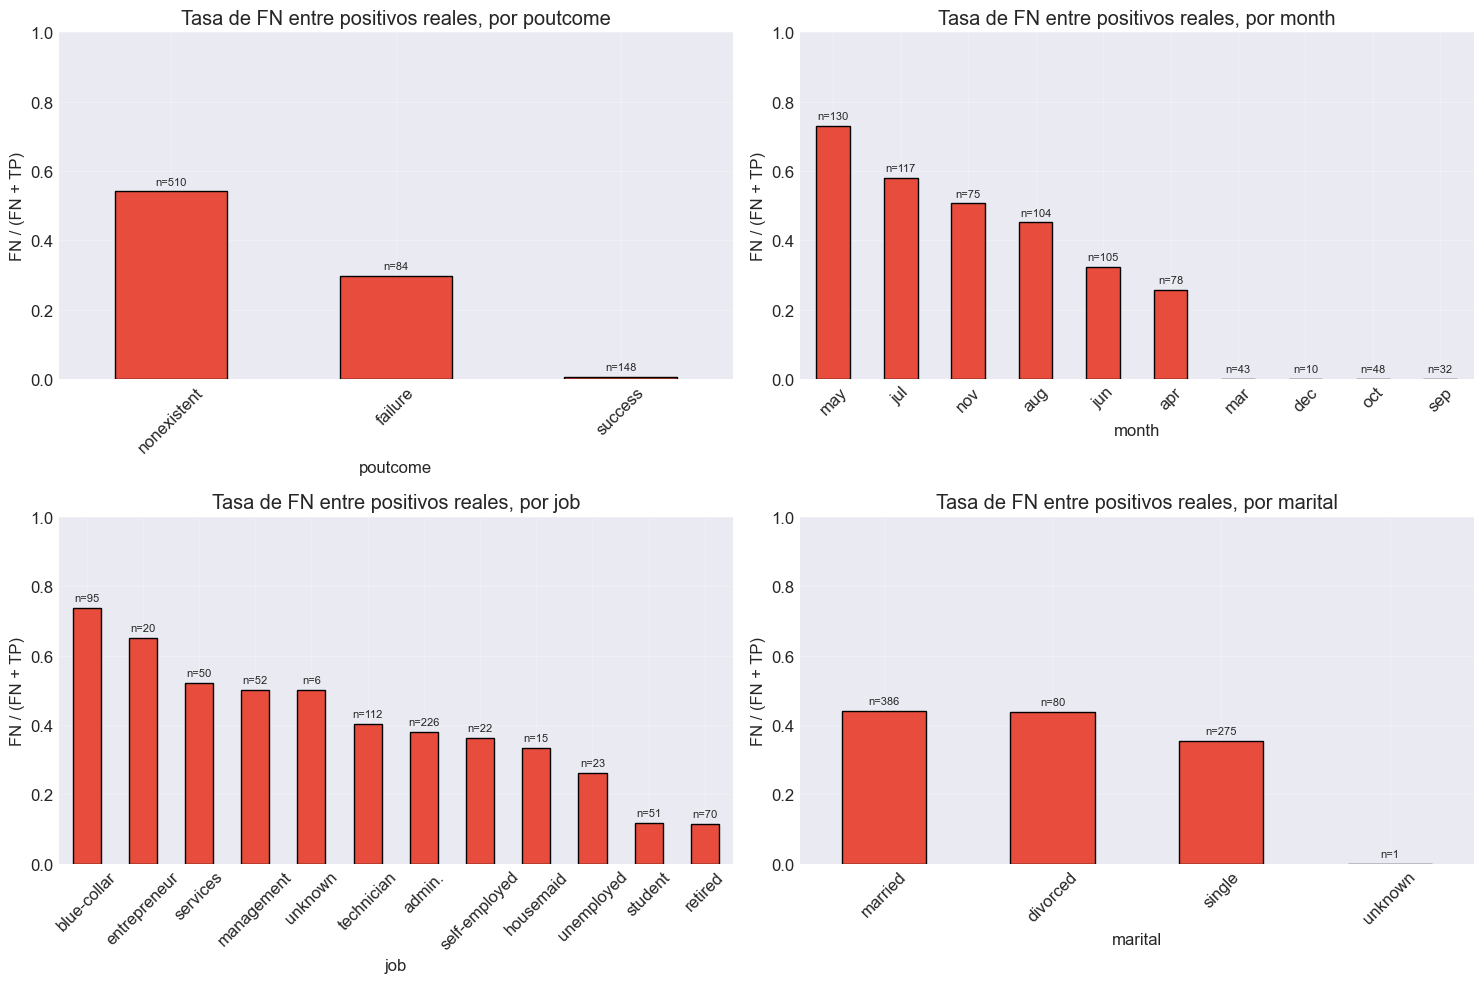

In [66]:
positivos = df_err[df_err["y_real"] == 1]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col in zip(axes.flat, ["poutcome", "month", "job", "marital"]):
    fn_rate = (positivos.groupby(col)["tipo"]
               .apply(lambda s: (s == "FN").mean())
               .sort_values(ascending=False))
    sizes = positivos[col].value_counts()
    fn_rate.plot.bar(ax=ax, color="#e74c3c", edgecolor="black")
    ax.set_title(f"Tasa de FN entre positivos reales, por {col}")
    ax.set_ylabel("FN / (FN + TP)")
    ax.set_ylim(0, 1)
    for i, (cat, rate) in enumerate(fn_rate.items()):
        ax.text(i, rate + 0.02, f"n={sizes[cat]}", ha="center", fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "error_analysis_segmented.png", dpi=150)
plt.show()

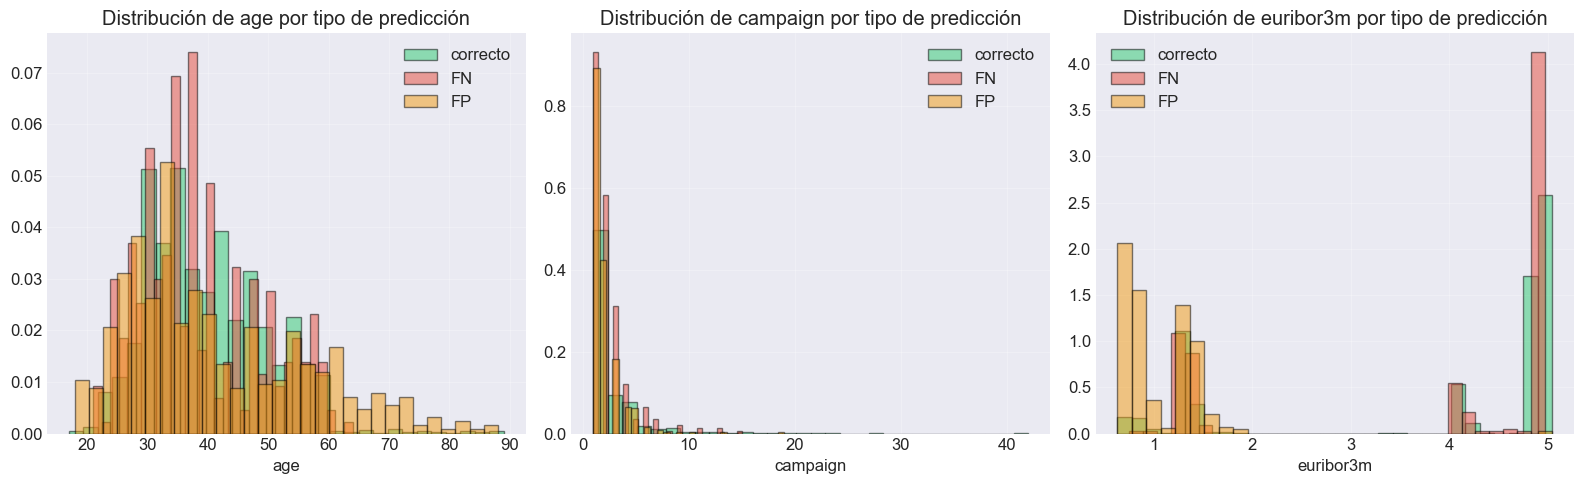

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["age", "campaign", "euribor3m"]):
    for tipo, color in [("correcto", "#2ecc71"), ("FN", "#e74c3c"), ("FP", "#f39c12")]:
        subset = df_err[df_err["tipo"] == tipo][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=tipo,
                color=color, edgecolor="black", density=True)
    ax.set_title(f"Distribución de {col} por tipo de predicción")
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / "error_analysis_numeric.png", dpi=150)
plt.show()

## 13. Conclusiones y decisión provisional

### ¿Qué modelos se compararon y por qué?
Cinco configuraciones cubriendo cuatro familias: Regresión Logística (baseline
de Entrega 1), Árbol de Decisión, Random Forest, SVM RBF y Random Forest
afinado con Optuna. Las familias cubren cuatro mecanismos distintos de
aprendizaje: lineal, reglas interpretables, bagging y kernel.

### ¿Cómo se evitó el data leakage?
- Split estratificado **antes** de cualquier transformación.
- Preprocesador encapsulado en `Pipeline`: las estadísticas se aprenden solo
  del fold de train de cada CV.
- SMOTE dentro de `imblearn.pipeline.Pipeline`: sintetiza solo en train.
- **Threshold óptimo seleccionado con out-of-fold predictions sobre train**
  vía `cross_val_predict`, sin tocar validation ni test.
- `duration` excluida desde el inicio (target leakage).
- `X_test` intacto en toda la entrega.

### ¿Cuál familia parece más prometedora?
La respuesta honesta está en la tabla de comparación. Las métricas relevantes
son AP en CV (con barras de error) y F1 @ threshold óptimo. Si dos modelos
están a menos de 1 std de distancia, son indistinguibles estadísticamente.
La interpretación final debe basarse en el modelo con mejor AP en CV,
considerando también estabilidad (std), interpretabilidad y costo
computacional.

### ¿Qué limitaciones siguen abiertas?
- El SVM se entrenó sobre submuestra de 8k filas por costo computacional.
  En la Entrega 3 podría usarse Nystroem para aproximar el kernel RBF y
  usar todo el train.
- El threshold óptimo maximiza F1 en OOF; en Entrega 3 se reemplazará por
  una función de costo real (costo de llamada vs ingreso esperado por
  suscripción).
- Las probabilidades del SVM con Platt scaling están comprimidas; esto
  afecta especialmente las decisiones al threshold por defecto.
- `X_test` sigue intacto. La evaluación final imparcial se reserva para
  la Entrega 3.

### Lectura honesta de los resultados

Random Forest (Optuna) lidera en AP de CV (0.4592 ± 0.0198), pero su ventaja
sobre la Regresión Logística baseline (0.4448 ± 0.0217) es de solo 0.0144,
dentro de una desviación estándar. **Estadísticamente, los dos modelos son
indistinguibles bajo este protocolo de validación.**

La selección final debe basarse en criterios secundarios:
- **Calibración:** LogReg tiene threshold óptimo en 0.20 (cerca de prevalencia
  natural). RF Optuna en 0.59 (sesgado por class_weight=balanced).
- **Interpretabilidad:** LogReg tiene coeficientes legibles directamente.
  RF requiere importancia de variables como proxy.
- **Costo computacional:** LogReg entrena en segundos. RF Optuna requirió
  ~30 trials de búsqueda guiada.

**Esto refuerza un hallazgo importante:** modelos complejos no siempre superan
a baselines lineales en datos tabulares de tamaño medio. En Entrega 3
exploraremos si feature engineering o boosting (XGBoost/LightGBM) abren
una brecha real sobre la baseline.

In [68]:
import joblib

joblib.dump(mejor_pipeline, REPORT_PATH / "mejor_pipeline_e2.joblib")

resumen_final = {
    "modelo_seleccionado": nombre_mejor,
    "threshold_optimo_OOF": float(thr_mejor),
    "AP_CV_mean": float(mejor_res["AP (CV mean)"]),
    "AP_CV_std":  float(mejor_res["AP (CV std)"]),
    "ROC_AUC_CV_mean": float(mejor_res["ROC-AUC (CV mean)"]),
    "F1_val_default": float(mejor_res["F1 @ 0.5 (val)"]),
    "F1_val_optimo":  float(mejor_res["F1 @ óptimo (val)"]),
}
pd.Series(resumen_final).to_frame("valor").to_csv(
    REPORT_PATH / "decision_provisional_e2.csv"
)

print(f"Pipeline guardado en {REPORT_PATH / 'mejor_pipeline_e2.joblib'}")
print(f"Resumen guardado en {REPORT_PATH / 'decision_provisional_e2.csv'}")
print("\nDecisión provisional Entrega 2:")
for k, v in resumen_final.items():
    print(f"  {k}: {v}")

Pipeline guardado en ..\report\mejor_pipeline_e2.joblib
Resumen guardado en ..\report\decision_provisional_e2.csv

Decisión provisional Entrega 2:
  modelo_seleccionado: Random Forest (Optuna)
  threshold_optimo_OOF: 0.5944218882955472
  AP_CV_mean: 0.45924221132357906
  AP_CV_std: 0.019754031335145732
  ROC_AUC_CV_mean: 0.79361118668515
  F1_val_default: 0.48497854077253216
  F1_val_optimo: 0.5116279069767442
